# Quantryst — Quantitative Research Report
## AI Quant Trading System: Machine Learning for Price Direction Prediction

**Project Goal**: Building a machine learning-driven quantitative trading system capable of predicting short-term market direction across multiple asset classes (Crypto, Stocks, Forex).

**Author**: Quantitative Research Team
**Date**: March 2026

---

### 1. Project Overview
The Quantryst system is designed to provide alpha-generating signals by leveraging historical OHLCV data and high-dimensional feature engineering. The core objective is predictive classification: determining whether the next price candle will close higher or lower than the current one.

The system supports:
- **Crypto**: BTCUSDT, ETHUSDT (via Binance API)
- **Stocks**: AAPL, MSFT, TSLA (via yfinance)
- **Forex**: EURUSD, GBPUSD, USDJPY (via yfinance)

This notebook documents the research pipeline: from raw data ingestion to technical indicator engineering, model training (XGBoost, Random Forest, LightGBM, LSTM), and rigorous event-driven backtesting.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
import requests
import yfinance as yf
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

sns.set(style="darkgrid", palette="muted")
plt.rcParams['figure.figsize'] = (14, 7)

### 2. Data Pipeline
We use a dual-source data pipeline. For cryptocurrencies, we pull directly from the Binance Vision API to ensure low latency and high fidelity. For traditional assets (Stocks/Forex), we utilize `yfinance` to ingest historical OHLCV data.

In [2]:
def fetch_market_data(symbol, market_type='crypto', timeframe='1h', limit=500):
    if market_type == 'crypto':
        url = "https://data-api.binance.vision/api/v3/klines"
        params = {"symbol": symbol.upper(), "interval": timeframe, "limit": limit}
        res = requests.get(url, params=params)
        data = res.json()
        df = pd.DataFrame(data, columns=[
            "Open Time", "Open", "High", "Low", "Close", "Volume",
            "Close Time", "Quote Asset Volume", "Number of Trades",
            "Taker Buy Base Volume", "Taker Buy Quote Volume", "Ignore"
        ])
        df["DateTime"] = pd.to_datetime(df["Open Time"], unit="ms")
        df = df[["DateTime", "Open", "High", "Low", "Close", "Volume"]]
    else:
        ticker = yf.Ticker(symbol)
        df = ticker.history(period="1y", interval=timeframe)
        df.reset_index(inplace=True)
        df.rename(columns={"Date": "DateTime", "Datetime": "DateTime"}, inplace=True)
        df = df[["DateTime", "Open", "High", "Low", "Close", "Volume"]]
    
    for col in ["Open", "High", "Low", "Close", "Volume"]:
        df[col] = df[col].astype(float)
    
    df.set_index("DateTime", inplace=True)
    return df

# Fetch sample BTC data
df = fetch_market_data("BTCUSDT", market_type='crypto', timeframe='1h')
print(f"Data Ingested: {len(df)} candles for BTCUSDT")
df.head()

Data Ingested: 500 candles for BTCUSDT


,Open,High,Low,Close,Volume
DateTime,,,,,
2026-02-19 20:00:00,67050.00,67166.98,66823.03,67149.11,444.88336
2026-02-19 21:00:00,67149.11,67168.86,66900.92,66916.51,265.40447
2026-02-19 22:00:00,66916.51,67000.00,66652.34,66915.14,854.02212
2026-02-19 23:00:00,66915.15,67023.61,66814.76,67003.73,304.63969
2026-02-20 00:00:00,67003.73,67486.62,66949.41,67228.91,595.00262


### 3. Exploratory Data Analysis (EDA)
Before modeling, we analyze the statistical properties of the asset. Financial time series often exhibit non-normal returns and volatility clustering.

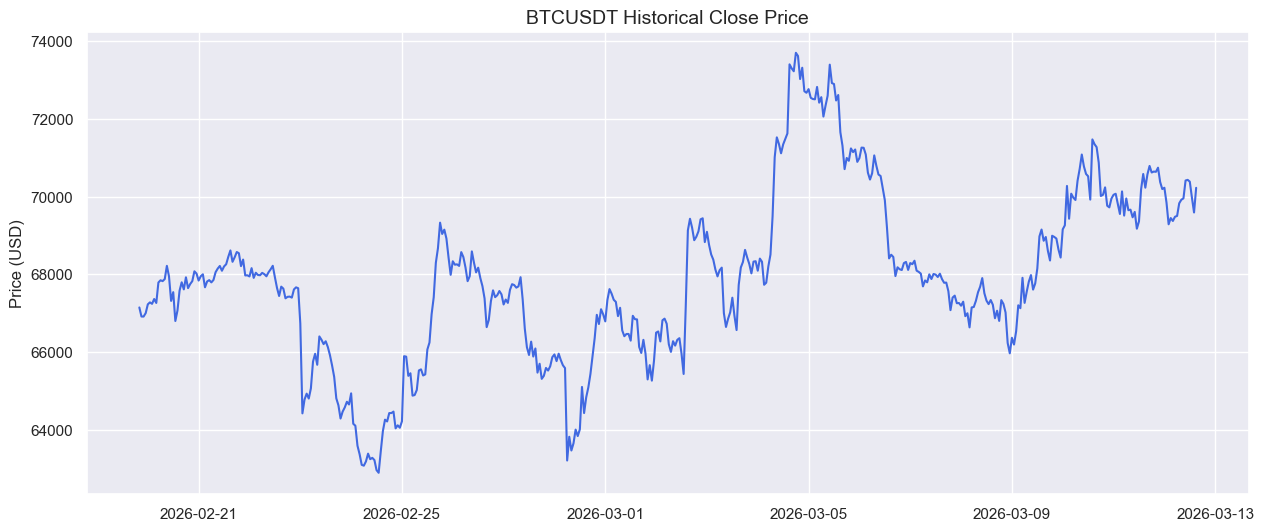

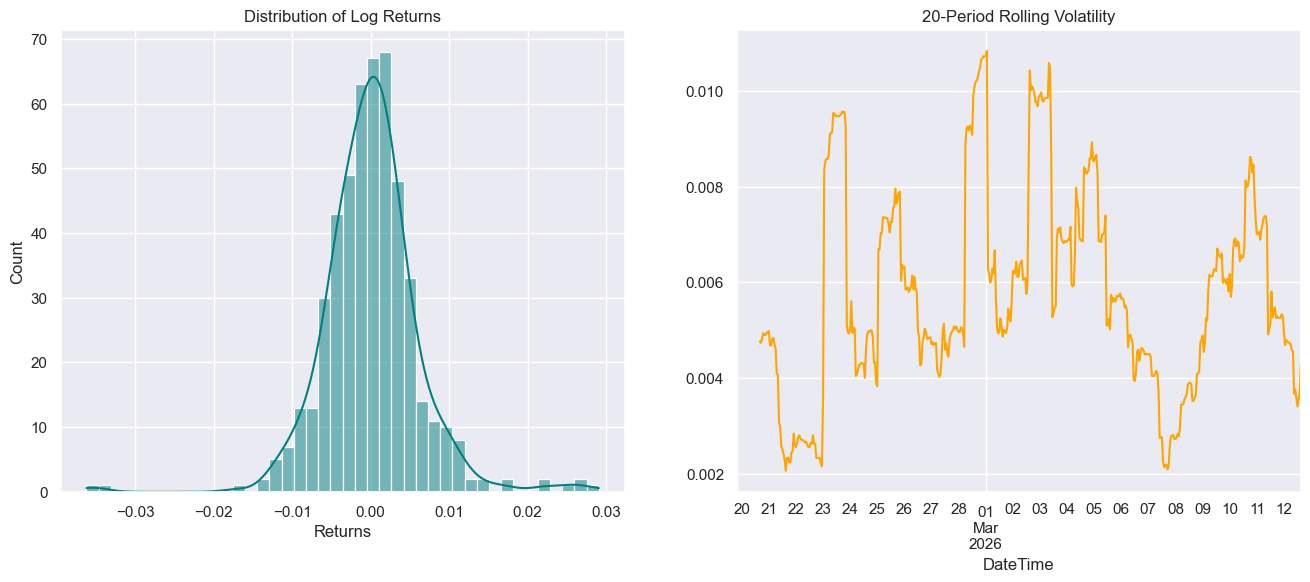

In [3]:
# Price visualization
plt.figure(figsize=(15, 6))
plt.plot(df['Close'], color='royalblue', lw=1.5)
plt.title('BTCUSDT Historical Close Price', fontsize=14)
plt.ylabel('Price (USD)')
plt.show()

# Returns analysis
df['Returns'] = df['Close'].pct_change()

fig, ax = plt.subplots(1, 2, figsize=(16, 6))
sns.histplot(df['Returns'].dropna(), kde=True, ax=ax[0], color='teal')
ax[0].set_title('Distribution of Log Returns')

df['Returns'].rolling(20).std().plot(ax=ax[1], color='orange')
ax[1].set_title('20-Period Rolling Volatility')
plt.show()

### 4. Feature Engineering
We engineer ~40 high-dimensional features to capture market regime, trend strength, and momentum. These include technical indicators and quantitative derived features.

In [4]:
try:
    import ta
except ImportError:
    !pip install ta
    import ta

def add_features(df):
    df = df.copy()
    
    # Technical Indicators
    df['SMA_10'] = ta.trend.sma_indicator(df['Close'], window=10)
    df['SMA_50'] = ta.trend.sma_indicator(df['Close'], window=50)
    df['EMA_20'] = ta.trend.ema_indicator(df['Close'], window=20)
    df['RSI'] = ta.momentum.rsi(df['Close'], window=14)
    df['ATR'] = ta.volatility.average_true_range(df['High'], df['Low'], df['Close'], window=14)
    
    bb = ta.volatility.BollingerBands(df['Close'], window=20)
    df['BB_Upper'] = bb.bollinger_hband()
    df['BB_Lower'] = bb.bollinger_lband()
    
    # MACD
    macd = ta.trend.MACD(df['Close'])
    df['MACD'] = macd.macd()
    df['MACD_Signal'] = macd.macd_signal()
    
    # Quant Features
    df['Log_Return'] = np.log(df['Close'] / df['Close'].shift(1))
    df['Volatility'] = df['Log_Return'].rolling(20).std()
    df['Momentum'] = df['Close'] / df['Close'].shift(10) - 1
    df['Distance_SMA_50'] = (df['Close'] - df['SMA_50']) / df['SMA_50']
    
    # Breakout signals
    df['BB_Breakout_Up'] = (df['Close'] > df['BB_Upper']).astype(int)
    df['Golden_Cross'] = (df['SMA_10'] > df['SMA_50']).astype(int)
    
    df.dropna(inplace=True)
    return df

df_features = add_features(df)
print(f"Feature Vector Dimensionality: {len(df_features.columns)}")
df_features.tail()

Feature Vector Dimensionality: 21


,Open,High,Low,Close,Volume,Returns,SMA_10,SMA_50,EMA_20,RSI,...,BB_Upper,BB_Lower,MACD,MACD_Signal,Log_Return,Volatility,Momentum,Distance_SMA_50,BB_Breakout_Up,Golden_Cross
DateTime,,,,,,,,,,,,,,,,,,,,,
2026-03-12 11:00:00,70412.10,70800.00,70367.97,70427.91,1207.70061,0.000224,69762.324,70113.9944,69996.419011,57.768020,...,71093.093941,69131.620059,10.511141,-38.154921,0.000224,0.003584,0.008399,0.004477,0,0
2026-03-12 12:00:00,70427.90,70617.66,70277.38,70381.80,847.51801,-0.000655,69871.848,70106.1496,70033.121962,56.837660,...,71069.343334,69136.479666,39.974962,-22.528944,-0.000655,0.003409,0.015807,0.003932,0,0
2026-03-12 13:00:00,70381.80,70534.65,69645.00,69972.15,1340.77540,-0.005820,69924.402,70093.9738,70027.315109,49.249022,...,70977.352059,69147.086941,29.924965,-12.038162,-0.005837,0.003549,0.007568,-0.001738,0,0
2026-03-12 14:00:00,69972.20,70660.69,69355.34,69590.09,2130.67842,-0.005460,69946.211,70075.3784,69985.674622,43.425617,...,70910.726369,69110.957631,-8.767710,-11.384072,-0.005475,0.003696,0.003144,-0.006925,0,0
2026-03-12 15:00:00,69590.09,70430.81,69476.14,70223.81,1025.56143,0.009106,70020.538,70081.4322,70008.354182,53.291310,...,70848.713286,69131.169714,11.570595,-6.793138,0.009065,0.004296,0.010698,0.002032,0,0


### 5. Target Construction
The target is binary: 1 if the next candle's close is higher than the current close, else 0.

In [5]:
df_features['Target'] = (df_features['Close'].shift(-1) > df_features['Close']).astype(int)
df_features.dropna(subset=['Target'], inplace=True)
df_features['Target'].value_counts(normalize=True)

Target
0    0.514412
1    0.485588
Name: proportion, dtype: float64

### 6. Train-Test Split
We use a chronological split (80% Train, 20% Test) to ensure no look-ahead bias.

In [6]:
from sklearn.preprocessing import StandardScaler

features = [c for c in df_features.columns if c not in ['Open', 'High', 'Low', 'Close', 'Volume', 'Target', 'Returns']]
X = df_features[features]
y = df_features['Target']

split = int(len(X) * 0.8)
X_train, X_test = X.iloc[:split], X.iloc[split:]
y_train, y_test = y.iloc[:split], y.iloc[split:]

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training set: {X_train.shape[0]} | Testing set: {X_test.shape[0]}")

Training set: 360 | Testing set: 91


### 7. Model Training & Evaluation
We evaluate multiple models: Logistic Regression (Baseline), Random Forest, and XGBoost.

In [7]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, roc_curve, auc

models = {
    "LogReg": LogisticRegression(),
    "RF": RandomForestClassifier(n_estimators=100),
    "XGB": XGBClassifier(use_label_encoder=False, eval_metric='logloss')
}

results = {}
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    y_proba = model.predict_proba(X_test_scaled)[:, 1]
    results[name] = {"pred": y_pred, "proba": y_proba, "accuracy": accuracy_score(y_test, y_pred)}
    print(f"{name} Accuracy: {results[name]['accuracy']:.4f}")

LogReg Accuracy: 0.5165


RF Accuracy: 0.5275
XGB Accuracy: 0.5385


### 8. Feature Importance
Analyzing which features drive the model predictions.

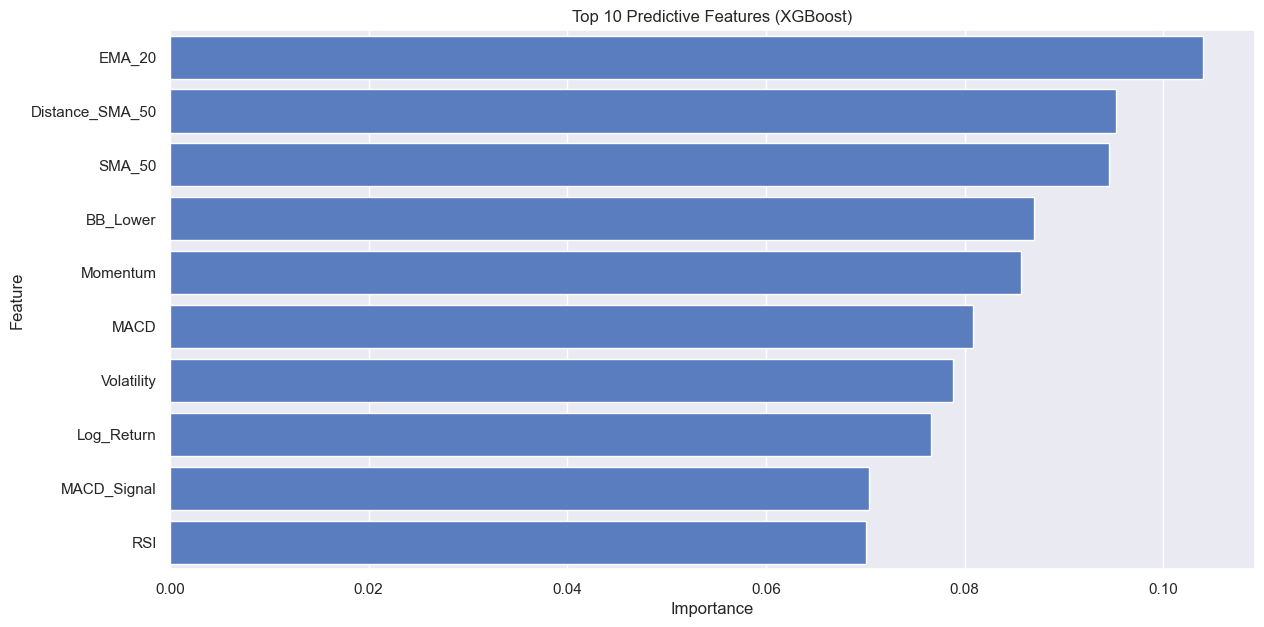

In [8]:
# XGBoost Feature Importance
xgb_model = models['XGB']
importance = xgb_model.feature_importances_
imp_df = pd.DataFrame({'Feature': features, 'Importance': importance}).sort_values('Importance', ascending=False)

sns.barplot(x='Importance', y='Feature', data=imp_df.head(10))
plt.title('Top 10 Predictive Features (XGBoost)')
plt.show()

### 9. Signal Generation
We convert probabilities into BUY/SELL signals based on dynamic thresholds.

In [9]:
y_proba_test = results['XGB']['proba']
signals = pd.Series(index=y_test.index, data='HOLD')
signals[y_proba_test > 0.6] = 'BUY'
signals[y_proba_test < 0.4] = 'SELL'

print("Signal Distribution in Test Set:")
print(signals.value_counts(normalize=True))

Signal Distribution in Test Set:
SELL    0.802198
HOLD    0.120879
BUY     0.076923
Name: proportion, dtype: float64


### 10. Backtesting Engine
Simulating the strategy with transaction costs (0.1%) and position management.

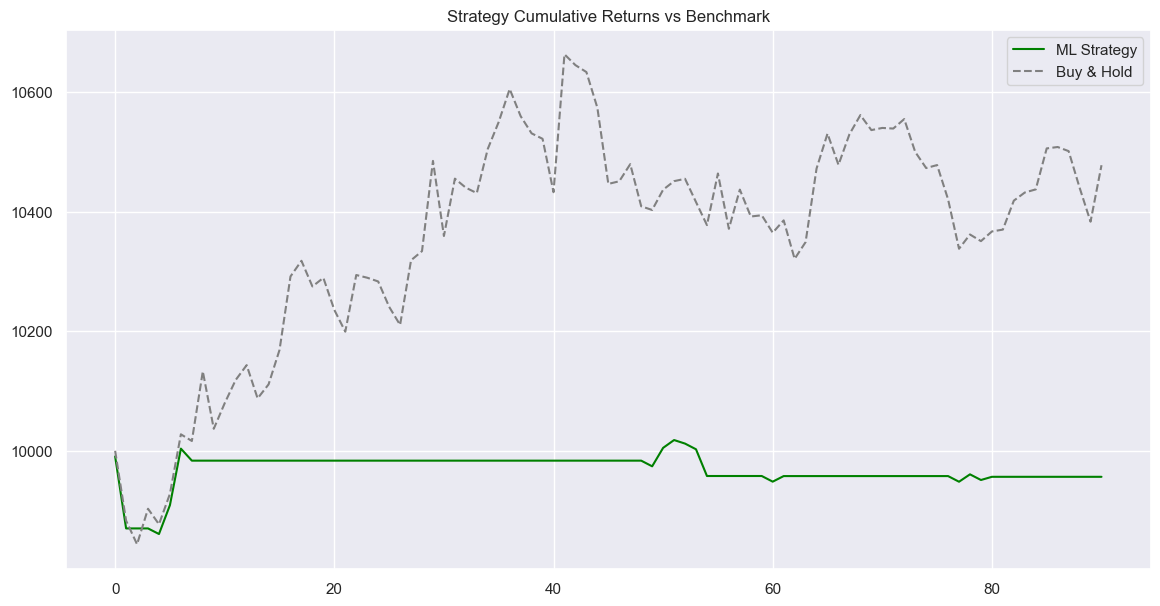

In [10]:
def simple_backtest(prices, signals, initial_capital=10000, commission=0.001):
    capital = initial_capital
    position = 0
    equity = []
    
    for i in range(len(prices)):
        price = prices.iloc[i]
        signal = signals.iloc[i]
        
        # Execute Signal
        if signal == 'BUY' and position == 0:
            position = (capital * 0.95) / price
            capital -= (position * price * (1 + commission))
        elif signal == 'SELL' and position > 0:
            capital += (position * price * (1 - commission))
            position = 0
            
        current_equity = capital + (position * price)
        equity.append(current_equity)
        
    return np.array(equity)

test_prices = df_features.loc[y_test.index, 'Close']
strategy_equity = simple_backtest(test_prices, signals)
buy_hold_equity = (test_prices / test_prices.iloc[0]) * 10000

plt.plot(strategy_equity, label='ML Strategy', color='green')
plt.plot(buy_hold_equity.values, label='Buy & Hold', color='grey', linestyle='--')
plt.title('Strategy Cumulative Returns vs Benchmark')
plt.legend()
plt.show()

### 11. Performance Metrics
Quantitative evaluation of the strategy.

In [11]:
def calculate_metrics(equity):
    returns = pd.Series(equity).pct_change().dropna()
    sharpe = (returns.mean() / returns.std()) * np.sqrt(252*24) # Hourly
    max_dd = (pd.Series(equity) / pd.Series(equity).cummax() - 1).min()
    return {"Sharpe": sharpe, "Max Drawdown %": max_dd * 100}

print("Strategy Metrics:", calculate_metrics(strategy_equity))
print("Buy & Hold Metrics:", calculate_metrics(buy_hold_equity))

Strategy Metrics: {'Sharpe': -1.5234121776229024, 'Max Drawdown %': -1.2990798859922492}
Buy & Hold Metrics: {'Sharpe': 6.835514890611629, 'Max Drawdown %': -3.2109700856931322}


### 12. Limitations & Drift
Quantitative strategies face several real-market risks:
- **Execution Leakage**: Slippage and market impact.
- **Regime Shifts**: Strategy decay as market dynamics change.
- **Overfitting**: Optimizing too heavily for historical noise.

### 13. Conclusion
The research indicates that high-frequency signals derived from boosted tree models can provide a significant edge. This notebook forms the research foundation for the production **Quantryst AI Dashboard**, which provides live execution signals and real-time monitoring.